# Fitting Donor-Acceptor FLIM Data

The donor **and** acceptor fluorescence decay profiles is to be described and fitted for determination of the resonance energy transfer rate.

$$\frac{d[D^*]}{dt} = - \frac{d[D]}{dt} = -(k_{f}^{D} + k_{r}^{DA})D^* + \phi^{D} \text{IRF}(t)$$

$$\frac{d[A^*]}{dt} = - \frac{d[A]}{dt} = -k_{f}^{A} A^* + k_{r}^{DA})D^* + \lambda^{DA} \bigg[ \frac{d[D^*]}{dt} (t) \bigg] + \phi^{A} \text{IRF}(t)$$

In the system of differential equations, the change in the population of excited and ground state donor and acceptor molecules is described.

Both molecules are assumed to decay from their excited state, $D^*$ and $A^*$, with the rate constants $k_{f}^{D}$ and $k_{f}^{A}$, respectively (i.e. monoexponentially). The energy transfer takes places between the excited donor molecule population, $[D^*]$, and thus excited molecules from the ground state acceptor population, $[A]$, with the rate constant $k_{r}^{DA}$ (superscript denotes direction of energy transfer from left to right). The ground state acceptor population is not included in the description of the acceptor population, because it is assumed that $[A] \gg [D^*]$.

The donor is excited via laser excitation, which is described by the instrument response function of the measurement setup, $\text{IRF}(t)$. It can be either approximted as a Gaussian or fitted to measured data and fitted to a multi-component Gaussian function. For testing and simulation purposes, $\tetx{IRF}(t)$ is modeled as
Gaussian function

$$\text{IRF}(t) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{1}{2} \big( \frac{t - \mu_{i}}{\sigma} \big)^{2}}$$

with the $\text{FWHM}$ of the $\text{IRF}$ as $2 \sqrt{2 \ ln 2} \ \sigma \approx 2.3548 \sigma$. 

The purpose of the model is to include two main error inherent to simultanous donor-acceptor measurement, either via FLIM or intensity-based: 1.) excitation of the acceptor by the laser at donor excitation wavelength ($\phi^{A}$) and 2.) bleed-through of the donor signal into the acceptor detection channel ($\lambda^{DA}$).
The cross-excitation is modeled as a fractional contribution of $\text{IRF}(t)$ to the excitation of $[A]$. This is determined by a sample, where only the acceptor molecule is expressed and it is excited at the donor wavelength. The spectral bleed-through, $\lambda^{DA}$, of the donor signal into the acceptor detection channel is modeled as a fractional addition of the current donor signal at $t$ to the acceptor signal at $t$ weighted by a constant. 


In [163]:
%reset -f
# Importing required modules and setting up matplotlib
from scipy.integrate import odeint
import scipy.optimize as optimize
from lmfit import minimize, Parameter, Parameters, report_fit
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

# Import PTU reading / decoding functions
import pq_decoding_functions

In [164]:
def da_flim_ODE(y, t, pars):
    '''
        da_flim_ode(y, t, pars) - Function
        
        Description:
            - function defining a system of differential equations for a donor-acceptor FRET-FLIM system
            - intended to be used with eval_ode() function, which calls scipy.odeint for numerical integration
        Input Arguments:
            - y: Vector holding the initial values for all involved species (here D0, D1, A0, and A1)
            - t: time vector generated by numpy.linspace (tStart, tEnd, tSteps = (tEnd-tStart)/dt)
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps) --- I.e. time-offset of donor signal
                pars[5]: offset - y-offset of decay histograms; same for both right now(!)
        Returned:
            - array of four values (dD0, dD1, dA0, dA1) of current integration step
    '''
    try:
        kf_D = pars['kf_D'].value
        k_r = pars['k_r'].value
        kf_A = pars['kf_A'].value
        sigma = pars['sigma'].value
        mu = pars['mu'].value
        offset = pars['offset'].value
        #y = [pars['D0'].value, pars['D1'].value, pars['A0'].value, pars['A1'].value]
        #t = t[0]
    except:
            kf_D, k_r, kf_A, sigma, mu = pars
            t = t
            
    def gauss_laser(t):
        out = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((t - mu) / sigma)**2)
        return(float(out))
        
    
    dD1 = -kf_D*y[1] - k_r*y[1] + gauss_laser(t)*y[0]
    dD0 = -dD1
    dA1 = -kf_A*y[3] + k_r*y[1]
    dA0 = -dA1
    return([dD0, dD1, dA0, dA1])


def eval_ode(y, t, pars):
    '''
        eval_ode(y, t, pars)  Function
        
        Description:
            - performs numerical integration of da_flim_ode() using scipy.odeint given y0, time axis, and parameters
        Input Arguments:
            - y: Vector holding the initial values for all involved species (here D0, D1, A0, and A1)
            - t: time vector generated by numpy.linspace (tStart, tEnd, tSteps = (tEnd-tStart)/dt)
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps)
                pars[5]: offset - y-offset of decay histograms; same for both right now(!)
                pars[6]: acceptor_shift - time offset of acceptor signal relative to donor signal
                
            
        Returned:
            - array (4 x tSteps); solution of SDE as defined in da_flim_ODE() given the input parameters (pars)
    '''
    try:
        offset =  pars['offset'].value
        acceptor_shift = pars['acceptor_shift'].value
        y0 = [pars['D0'].value, pars['D1'].value, pars['A0'].value, pars['A1'].value]
        sim_params = pars
    except:
        offset = pars[5]
        acceptor_shift = pars[6]
        y0 = y
        sim_params = pars[0:5]
    
    sol = odeint(da_flim_ODE, y0, t, hmax = dt, args = (sim_params, ))
    sol += offset
    sol[:, 3] = np.roll(sol[:, 3], int(acceptor_shift)) # Only displacing excited acceptor signal; displacing ground state it pointless
    
    return(sol)


def residuals(pars, t, data, weighted = False):
    '''
        residuals(pars, t, data, weighted) - Function
        Description:
            - calculates residuals of input data array (4 x tSteps) vs. simulated donor-acceptor FLIM-FRET system given the input parameters
        Input Arguments:
            - pars: vector or Parameters() object (from lmfit.Parameters) with simulation parameters
                pars[0]: kf_D - donor decay constant (1/tau)
                pars[1]: k_r - transfer rate
                pars[2]: kf_A - acceptor decay constant
                pars[3]: sigma - Gauss pulse width in time (in ps), FWHM = 2.3*sigma
                pars[4]: mu - mean of Gauss pulse (in ps)
                pars[5]: offset - y-offset of decay histograms; same for both right now(!)
                pars[6]: acceptor_shift - time offset of acceptor signal relative to donor signal
            - t: time axis vector generated by numpy.linspace()
            - data: (4 x tSteps) array holding solution of da_flim_ode()
            - weighted: (boolean) If true, residuals are weighted with 1/sqrt(data)
        Returned:
            - 1D vector of residuals of D1 and A1 decays
    '''
    
    model = eval_ode(y0, t, pars)

    if(weighted == True):
        weights = 1.0/np.sqrt(model)
        resids1 = ((model[:, 1] - data[:, 1]) * weights[:, 1])**2
        resids2 = ((model[:, 3] - data[:, 3]) * weights[:, 3])**2
        
    else:
        resids1 = (model[:, 1] - data[:, 1])**2 # In real measurements, we only have D_1 and A_1, so we only calculate residuals for them
        resids2 = (model[:, 3] - data[:, 3])**2
    
    resids = np.hstack((resids1, resids2))
    #resids = np.transpose(resids)
    return(resids)

In [197]:
# Setting up the simulation time axis and simulation parameters
tStart = 0
tEnd = 51000
dt = 16
tSteps = int((tEnd - tStart) / dt)
t = np.linspace(tStart, tEnd, tSteps)

y0 = [3000, 0, 3000, 0]
kf_D, k_r, kf_A, sigma, mu, offset, acceptor_shift = 1/2500, 1/3000, 1/1400, 100, 5000, 20, 50
sim_params = np.array((kf_D, k_r, kf_A, sigma, mu, offset, acceptor_shift))

## Defining lmfit.Parameters object
params = Parameters()
params.add('D0', value = 3000, min = 1, max = 100000)
params.add('A0', value = 3000, min = 1, max = 100000)
params.add('D1', value = 0, min = 1, max = 100000)
params.add('A1', value = 0, min = 1, max = 100000)
params.add('kf_D', value = 1/2490, min = 1/2300, max = 1/2800)
params.add('k_r', value = 1/5000, min = 1/500, max = 1/10000)
params.add('kf_A', value = 1/1510, min = 1/1200, max = 1/1600)
params.add('sigma', value = 110, min = 10, max = 300)
params.add('mu', value = 4000, min = 900, max = 7000)
params.add('offset', value = 2, min = 0, max = 100)
params.add('acceptor_shift', value = -30, min = -50, max = 50)

(3187, 4)


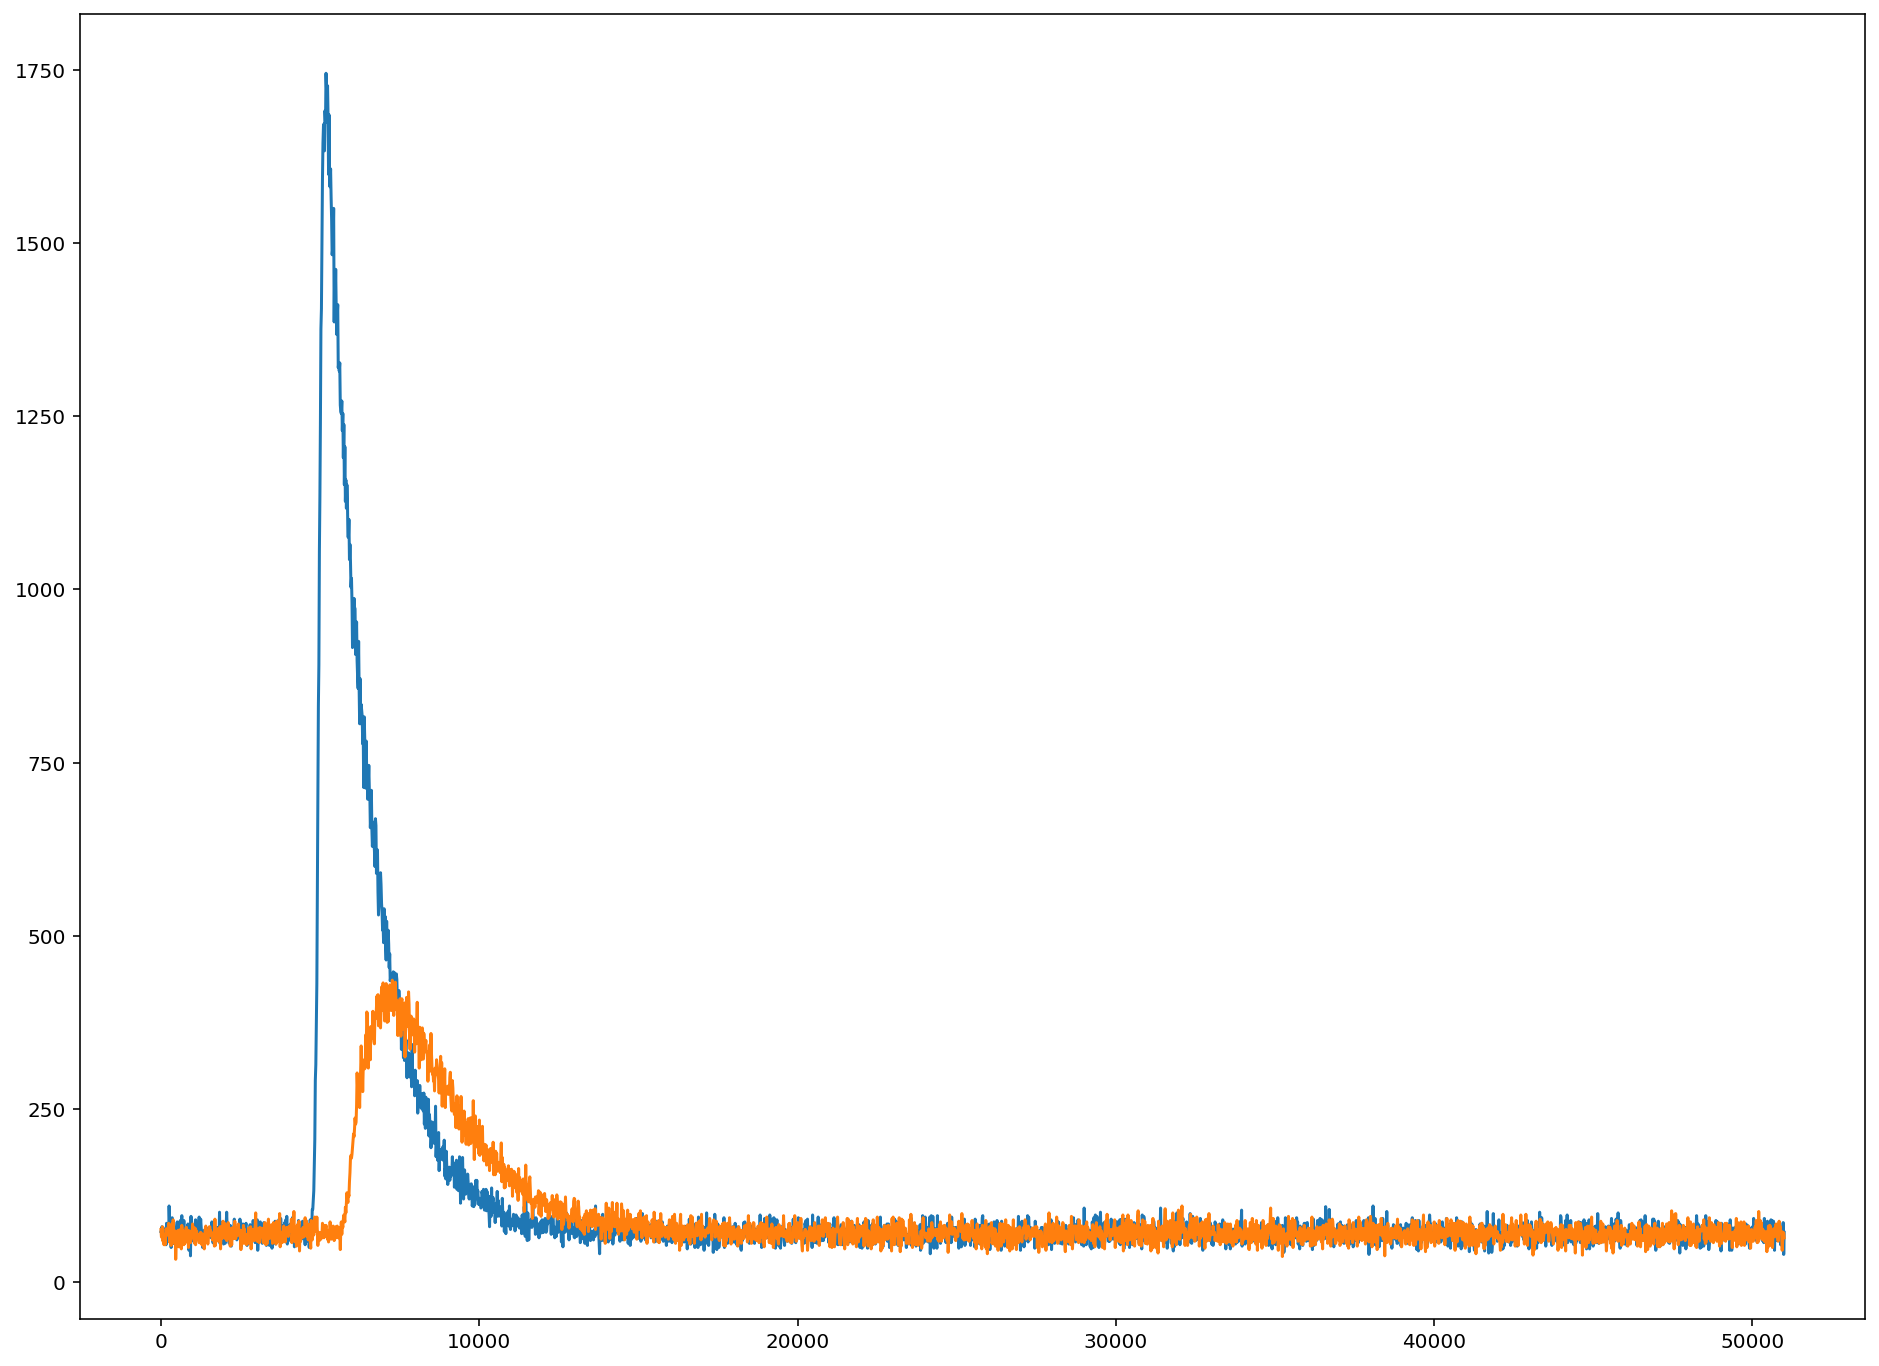

In [198]:
# Calculating example data and adding noise
noise = 50 # lambda for Poisson noise; equals offset for fitting function

sim_data = eval_ode(y0, t, sim_params)
sim_data[:, 1] += np.random.poisson(noise, len(sim_data[:, 0]))
sim_data[:, 1] = np.random.poisson(sim_data[:, 1], len(sim_data[:, 0]))
sim_data[:, 3] += np.random.poisson(noise, len(sim_data[:, 0]))
sim_data[:, 3] = np.random.poisson(sim_data[:, 3], len(sim_data[:, 0]))

print(sim_data.shape)

plt.plot(t, sim_data[:, 1])
plt.plot(t, sim_data[:, 3])

In [180]:
## Fitting the simulated data
fit = minimize(residuals, params, args = (t, sim_data, True), method = 'least_squares')

1.6246331138239531
1.7235334170929857


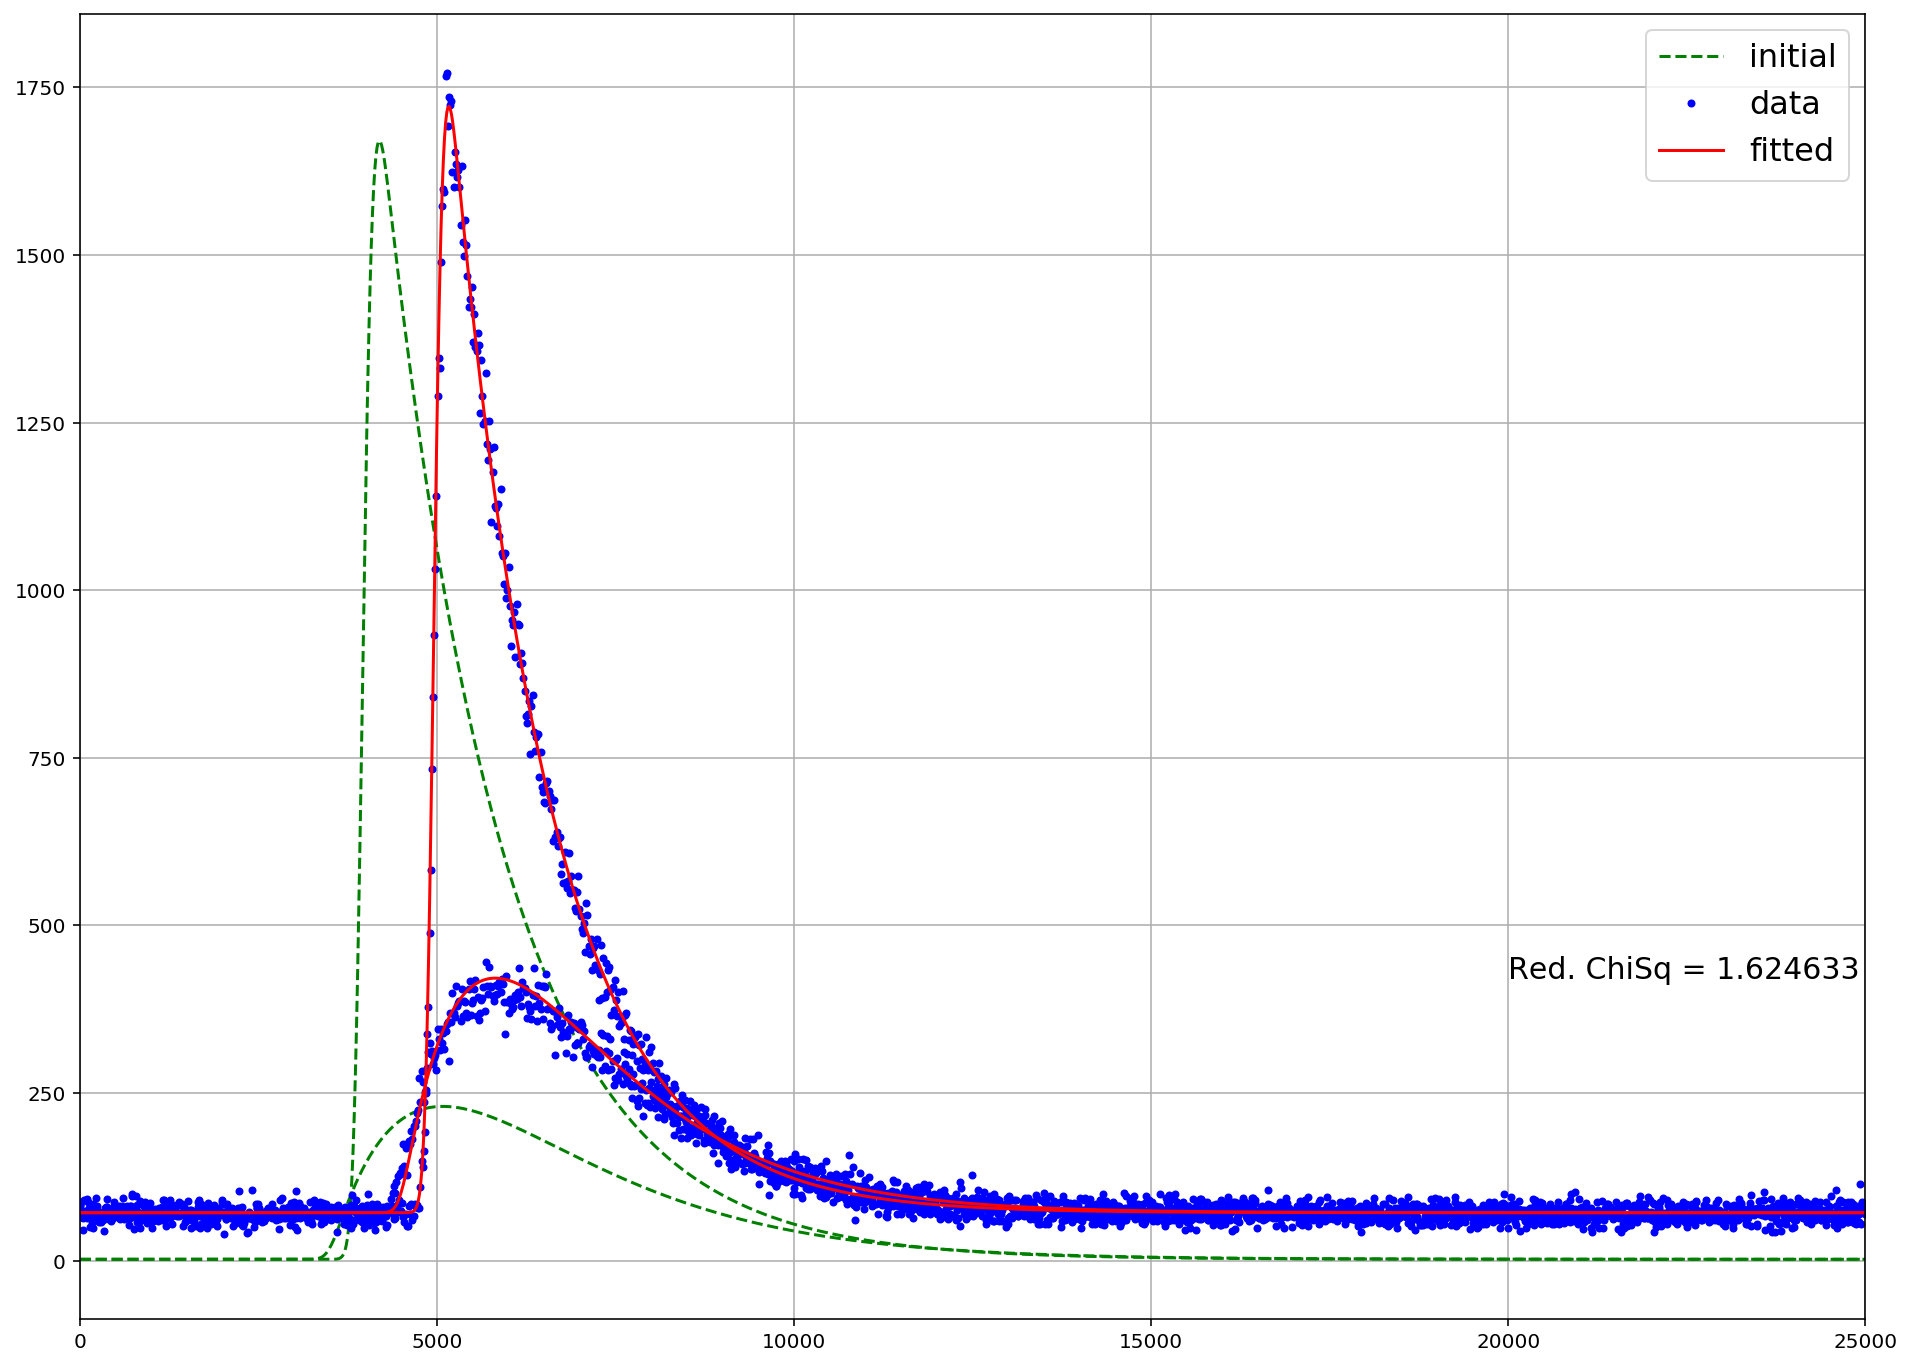

In [181]:
fit_params = [fit.params['kf_D'].value,
              fit.params['k_r'].value,
              fit.params['kf_A'].value,
              fit.params['sigma'].value,
              fit.params['mu'].value,
              fit.params['offset'].value,
              fit.params['acceptor_shift'].value]
initial_params = [params['kf_D'].value,
                  params['k_r'].value,
                  params['kf_A'].value,
                  params['sigma'].value,
                  params['mu'].value,
                  params['offset'].value,
                  params['acceptor_shift'].value]

#fitted = odeint(da_flim_ODE, y0_guess, t, hmax = dt, args = (fit_params, ))
#initial = odeint(da_flim_ODE, y0_guess, t, hmax = dt, args = (initial_params, ))
initial = eval_ode(y0, t, initial_params)
fitted = eval_ode(y0, t, fit_params)


# Manually calculating chi-squared
donor_resids = np.sum((sim_data[:, 1] - fitted[:, 1])**2 / fitted[:, 1])
redchi_D = donor_resids / (len(t) - len(fit_params) - 1)
print(redchi_D)
acceptor_resids = np.sum((sim_data[:, 3] - fitted[:, 3])**2 / fitted[:, 3])
redchi_A = acceptor_resids / (len(t) - len(fit_params) - 1)
print(redchi_A)

plt.plot(t, initial[:, 1], 'g--', label = 'initial')
plt.plot(t, initial[:, 3], 'g--')
plt.plot(t, sim_data[:, 1], 'b.', label = 'data')
plt.plot(t, sim_data[:, 3], 'b.')
plt.plot(t, fitted[:, 1], 'r-', label = 'fitted')
plt.plot(t, fitted[:, 3], 'r-')
plt.xlim(0, 25000)
plt.yscale('linear')
plt.grid()
plt.legend(loc = 'best')
plt.text(20000, 420, 'Red. ChiSq = %f' % redchi_D, fontsize = 15)
plt.show()

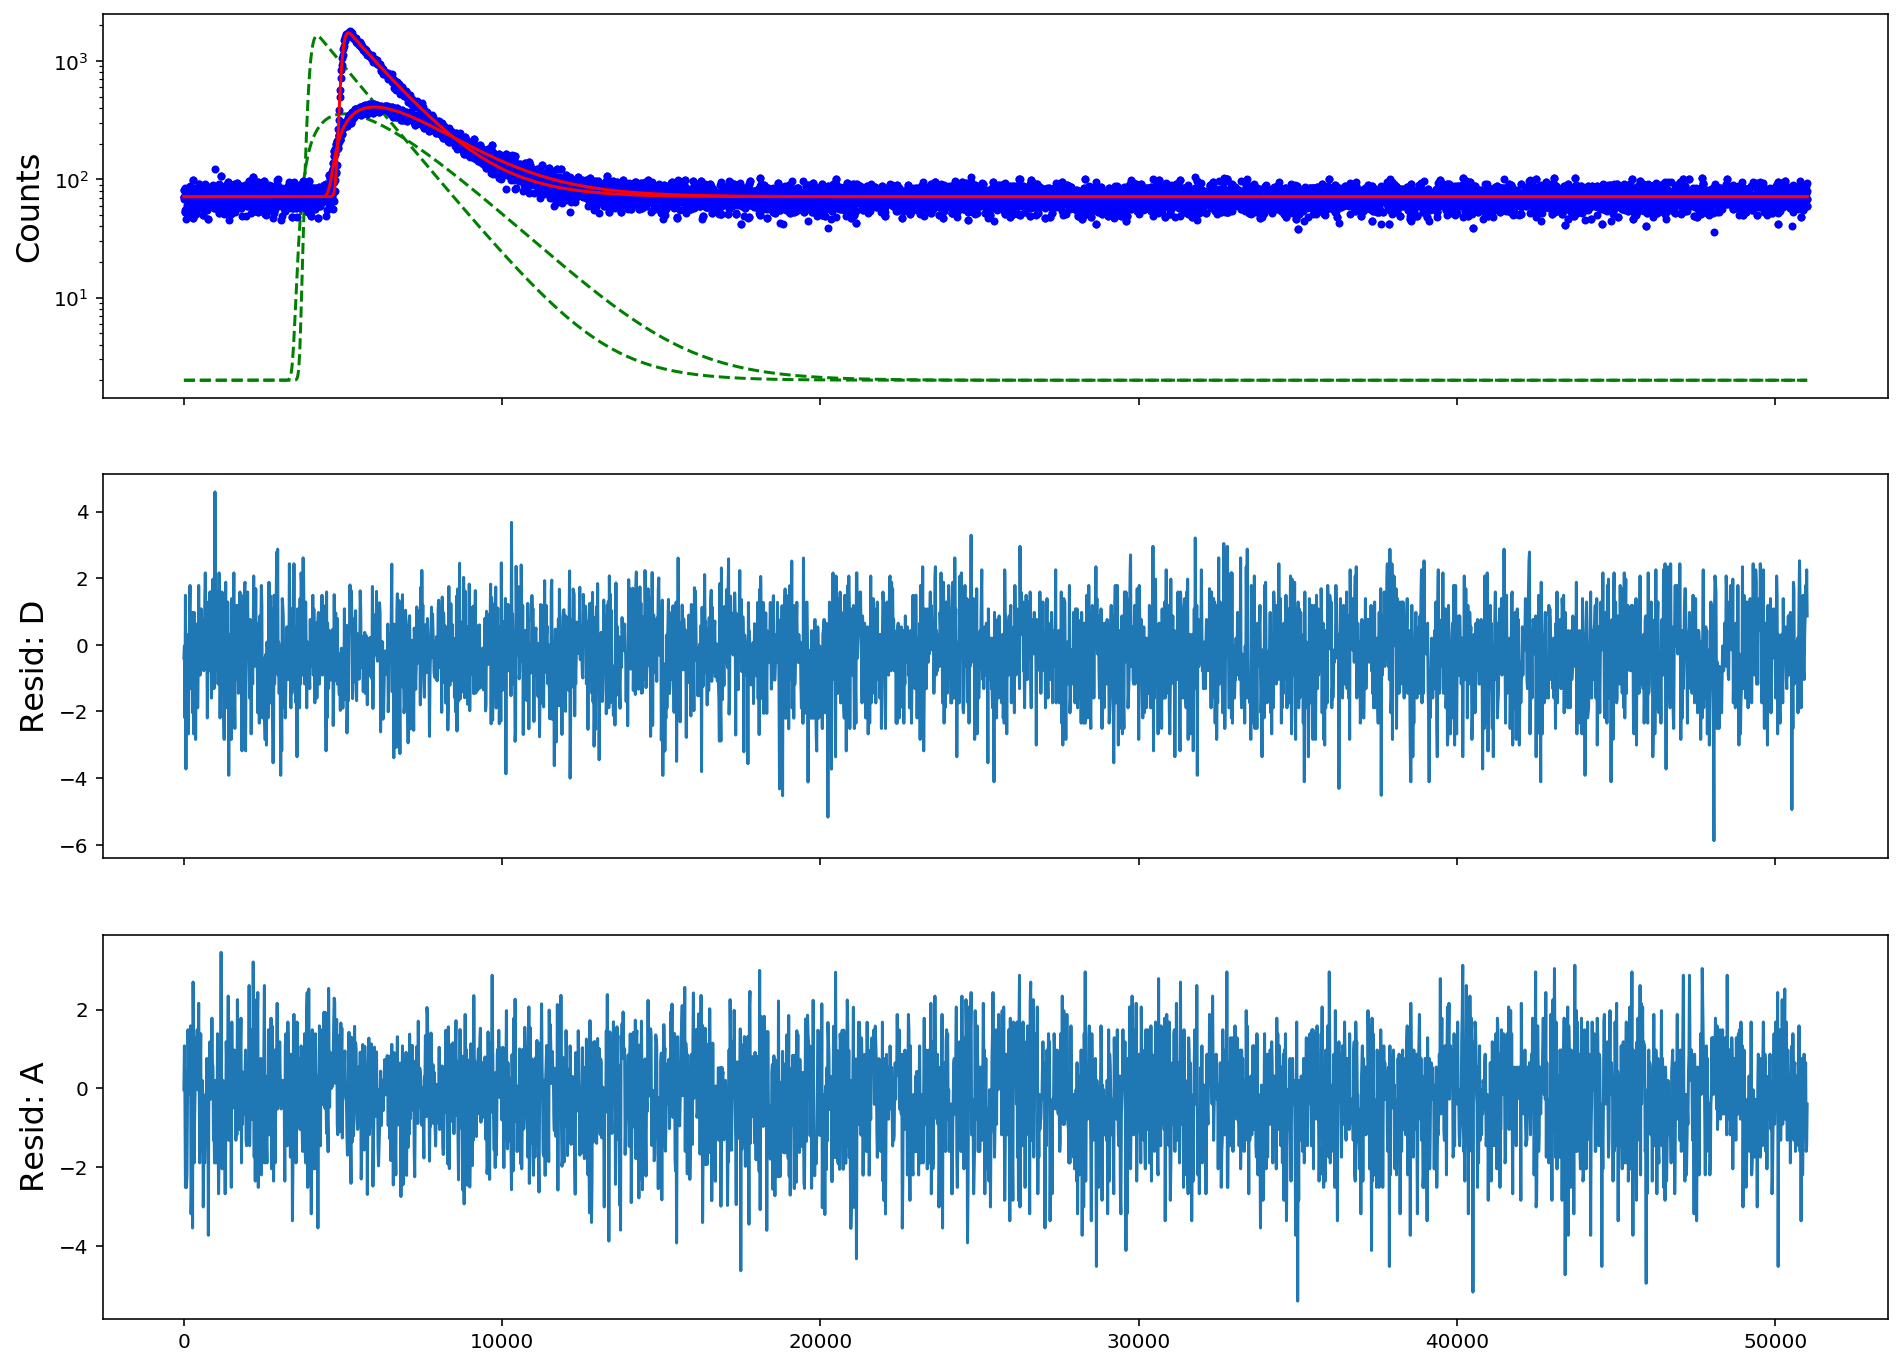

In [174]:
fig, ax = plt.subplots(3, 1, sharex = True)
ax[0].plot(t, initial[:, 1], 'g--', label = 'initial')
ax[0].plot(t, initial[:, 3], 'g--')
ax[0].plot(t, sim_data[:, 1], 'b.', label = 'data')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, sim_data[:, 3], 'b.')
ax[0].plot(t, fitted[:, 1], 'r-', label = 'fitted')
ax[0].plot(t, fitted[:, 3], 'r-')
ax[0].set(yscale = 'log', ylabel = 'Counts')
ax[1].plot(t, (sim_data[:, 1] - fitted[:, 1])*1/np.sqrt(sim_data[:, 1]), '-')
ax[1].set(ylabel = 'Resid: D')
ax[2].plot(t, (sim_data[:, 3] - fitted[:, 3])**1/np.sqrt(sim_data[:, 3]), '-')
ax[2].set(ylabel = 'Resid: A')
plt.show()

In [194]:
## Get left flank of decays for time offset determination --> required for proper time offset guessing
## Returns index at which left decay flank
def get_decay_flank(decay):
    first_derivative = np.diff(decay, n = 1)
    
    plt.plot(first_derivative)
    
    max_rise = np.where(max(first_derivative))
    
    return(max_rise)

(array([0]),)

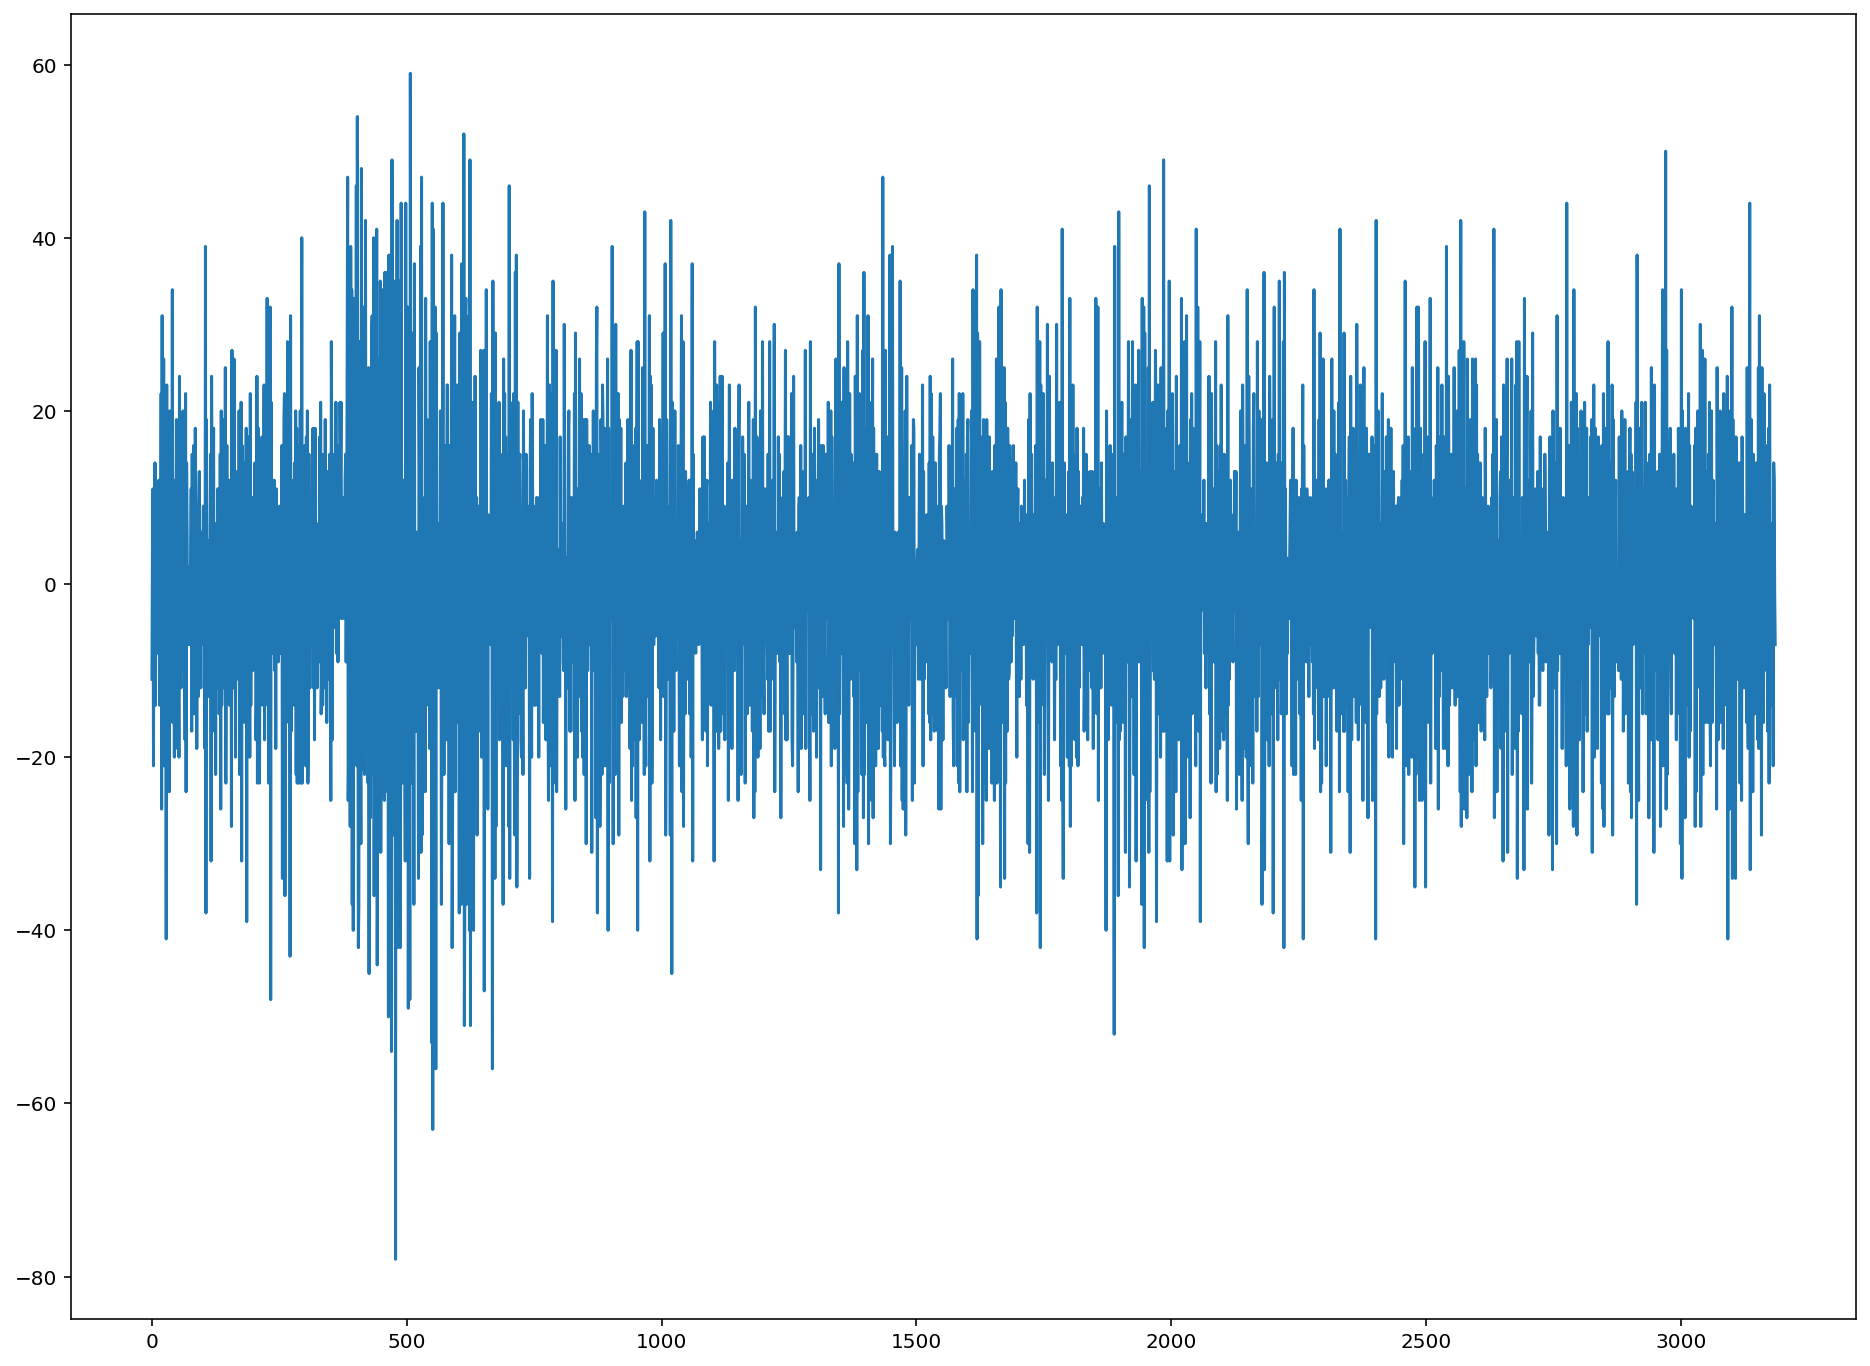

In [199]:
get_decay_flank(sim_data[:, 3])

In [ ]:
#test = pq_decoding_functions.readPTUData("data/191221_MicroscopeBenchmark_with_FPs.sptw/TCSPC_Benchmark_EGFP_NF488_14/TCSPC_Benchmark_EGFP_NF488_14_1.ptu")
